<div align="center">
  <b><br>
  <b><br>
  <b><font color="white" size="8">PROCESAMIENTO DE DATOS DEL GOES-19 CON PYTHON</font><br>
  <b><br>
  <b><font color="white" size="5">Joao Huamán</font><br>
  <b><br>
  <b><font color="white" size="4">01 de abril de 2026</font><br>
  <b><br>
</div>

Primero instalemos las librerias que vamos a utilizar:

In [1]:
!pip install cartopy
!pip install netCDF4
!pip install GOES
!pip install custom-color-palette

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 89.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.3.0 which is i

Ahora, montemos nuestro Google drive en el entorno del Colab:

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Creemos la carpeta de trabajo del ABI (por si aún no ha sido creada):

In [3]:
import os
os.makedirs('/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/ABI/',exist_ok=True)

Creemos la carpeta de trabajo del GLM (por si aún no ha sido creada):

In [4]:
import os
os.makedirs('/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/',exist_ok=True)

Descargamos imagenes del canal 13

In [5]:
import GOES

flist = GOES.download('goes19',
                      'ABI-L2-CMIPF',
                      DateTimeIni='20250613-053000',
                      DateTimeFin='20250613-053100',
                      channel=['13'],
                      path_out='/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/ABI/')

Files:
  OR_ABI-L2-CMIPF-M6C13_G19_s20251640530217_e20251640539536_c20251640539580.nc already exists.


Guardemos el nombre de cada archivo en una variable:

In [6]:
file_c13 = flist[0]

Descargamos datos del GLM

In [7]:
flist_GLM = GOES.download('goes19',
                         'GLM-L2-LCFA',
                         DateTimeIni='20250613-052000',
                         DateTimeFin='20250613-054000',
                         path_out='/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/')

Files:
  OR_GLM-L2-LCFA_G19_s20251640520000_e20251640520200_c20251640520220.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640520200_e20251640520400_c20251640520423.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640520400_e20251640521000_c20251640521019.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640521000_e20251640521200_c20251640521222.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640521200_e20251640521400_c20251640521421.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640521400_e20251640522000_c20251640522018.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640522000_e20251640522200_c20251640522221.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640522200_e20251640522400_c20251640522417.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640522400_e20251640523000_c20251640523019.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640523000_e20251640523200_c20251640523218.nc already exists.
  OR_GLM-L2-LCFA_G19_s20251640523200_e20251640523400_c20251640523418.nc already exists.
  OR_GLM-L2-LCFA_G19_s202

Buscaremos los archivos que se encuentren dentro un intervalo de tiempo:

In [8]:
GLM_files = GOES.locate_files('/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/',
                              'OR_GLM*.nc',
                              '20250613-052500',
                              '20250613-053500')

Listemos los archivos:

In [9]:
print(*GLM_files, sep='\n')

/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640525000_e20251640525200_c20251640525218.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640525200_e20251640525400_c20251640525421.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640525400_e20251640526000_c20251640526017.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640526000_e20251640526200_c20251640526221.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640526200_e20251640526400_c20251640526417.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640526400_e20251640527000_c20251640527019.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640527000_e20251640527200_c20251640527214.nc
/content/drive/MyDrive/Curso_procesamient

# 1- GLM

### Grafiquemos la ocurrencia de los flashes:

In [10]:
import GOES

ds = GOES.open_mfdataset(GLM_files)


Veamos el contenido de **ds**:

In [11]:
print(ds)

<class 'GOES.processing.processing_data.open_mfdataset'>

number files: 30
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640525000_e20251640525200_c20251640525218.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640525200_e20251640525400_c20251640525421.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640525400_e20251640526000_c20251640526017.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640526000_e20251640526200_c20251640526221.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640526200_e20251640526400_c20251640526417.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640526400_e20251640527000_c20251640527019.nc
/content/drive/MyDrive/Curso_procesamiento_datos_GOES19/GOES19/GLM/OR_GLM-L2-LCFA_G19_s20251640527000_e

Extraemos las coordenadas de los flashes:

In [12]:
# Extraemos las coordenadas de los flashes
flash_lon = ds.variable('flash_lon')
flash_lat = ds.variable('flash_lat')

In [13]:
print(flash_lon.data)

[ -73.41914  -121.763435 -101.01608  ... -103.66409   -74.63129
 -121.76459 ]


In [14]:
# Extraemos y definimos atributos para nuestro gráfico
sat = ds.attribute('platform_ID')[0]
title = 'Ocurrencia de Flash'
long_name = 'Hora de ocurrencia'
units = 'UTC'

In [15]:
# Extraemos el rango de tiempo que abarcan todos los archivos
time_bounds = ds.variable('product_time_bounds')
time_start = time_bounds.data[0,0]
time_end = time_bounds.data[-1,-1]

In [16]:
# Calculamos el tiempo medio de cada descarga eléctrica
ti = ds.variable('flash_time_offset_of_first_event')
tf = ds.variable('flash_time_offset_of_last_event')
flash_time = ti.data+(tf.data-ti.data)/2.0

In [17]:
print(flash_time)

[real_datetime(2025, 6, 13, 5, 24, 59, 344435)
 real_datetime(2025, 6, 13, 5, 24, 59, 997521)
 real_datetime(2025, 6, 13, 5, 24, 59, 577326) ...
 real_datetime(2025, 6, 13, 5, 34, 58, 376253)
 real_datetime(2025, 6, 13, 5, 34, 59, 44980)
 real_datetime(2025, 6, 13, 5, 34, 58, 650724)]


In [18]:
# Convertimos el tiempo medio en número:
from matplotlib.dates import date2num
flash_time_num = date2num(flash_time)

In [19]:
print(flash_time_num)

[20252.22568686 20252.22569442 20252.22568955 ... 20252.2326201
 20252.23262784 20252.23262327]


In [20]:
# Creación de una paleta de colores personalizada

import custom_color_palette as ccp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

ncols = 10

# Definimos los colores y el intervalo que ocupa en la paleta
palette = [['gold','orange','red','darkviolet','violet'], # sequencia de colores o paleta de matplotlib
           ccp.range(1,ncols,1) # intervalo que abarcan los colores
           ]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([palette], extend='both')

# Creamos unos parametros adicionales
cbticks = np.linspace(date2num(time_start),date2num(time_end),ncols) # creates ticks for colorbar
norm = Normalize(vmin=cbticks[0], vmax=cbticks[-1]) # calculates norm

In [21]:
print(cbticks)

[20252.22569444 20252.22646605 20252.22723765 20252.22800926
 20252.22878086 20252.22955247 20252.23032407 20252.23109568
 20252.23186728 20252.23263889]


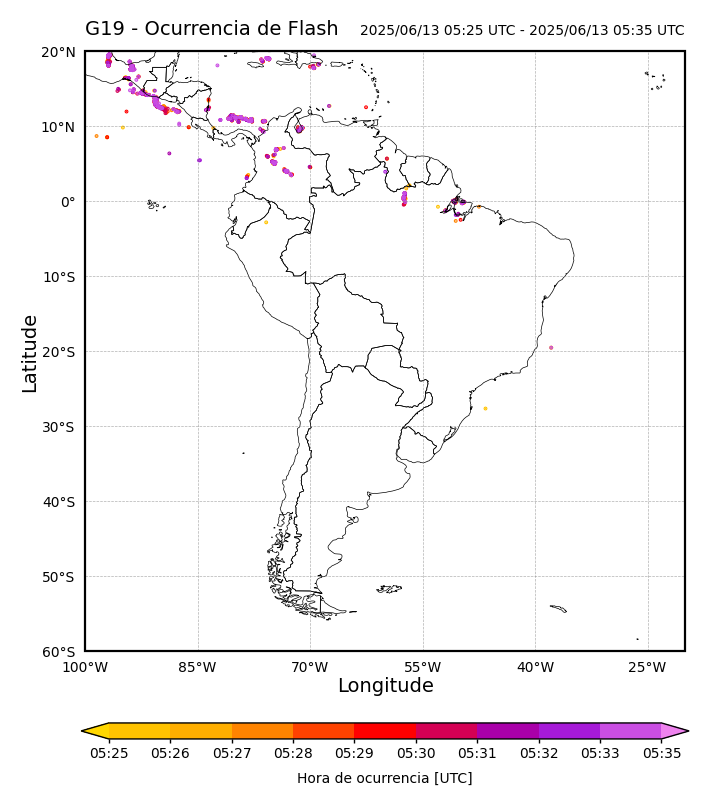

In [22]:
# Graficando las descargas eléctricas

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

domain = [-100.0,-20.0,-60.0,20.0]
proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='black', linewidth=0.25) # Adicionamos los limites

img = ax.scatter(flash_lon.data, flash_lat.data, s=0.15, c=flash_time_num, cmap=cmap, norm=norm,
                 marker='o', transform=ccrs.PlateCarree())

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, format=DateFormatter('%H:%M'), extend='both',
                  spacing='proportional', orientation='horizontal',
                  cax=fig.add_axes([0.12, 0.05, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - {}'.format(sat, title), fontsize=7, loc='left')
ax.set_title('{:%Y/%m/%d %H:%M UTC} - {:%Y/%m/%d %H:%M UTC}'.format(time_start, time_end),
             fontsize=5, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_FlashOccurrence.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [23]:
del ds, flash_lon, flash_lat, flash_time, flash_time_num, img, fig

### Grafiquemos la densidad de los flashes:

In [24]:
import GOES

ds = GOES.open_mfdataset(GLM_files)

# Extraemos las coordenadas de los flashes
flash_lon = ds.variable('flash_lon')
flash_lat = ds.variable('flash_lat')

# Extraemos y definimos atributos para nuestro gráfico
sat = ds.attribute('platform_ID')[0]
title = 'Densidad de Flash'
long_name = 'Densidad de Flash'
units = '#Flash/(8x8Km.10min)'

# Extraemos el rango de tiempo que abarcan todos los archivos
time_bounds = ds.variable('product_time_bounds')
time_start = time_bounds.data[0,0]
time_end = time_bounds.data[-1,-1]

In [25]:
print(flash_lat.data)

[  4.046187  -21.300032   40.22413   ...  17.95028     5.1513352
 -21.29984  ]


In [26]:
# Creando una grilla para acumular los flashes
domain = [-100.0,-20.0,-60.0,20.0]
pix_resol = 8.0 #km
gridmap_LonCor, gridmap_LatCor = GOES.create_gridmap(domain, PixResol=pix_resol)

In [27]:
# Acumulamos los flashes
dens = GOES.accumulate_in_gridmap(gridmap_LonCor, gridmap_LatCor, flash_lon, flash_lat)

    There are 1483 occurrences inside gridmap



In [28]:
# Creación de una paleta de colores personalizada

import custom_color_palette as ccp

# Definimos los colores y el intervalo que ocupa en la paleta
paleta_1 = [['black'],
            [0,1]
            ]

paleta_2 = [['yellow','darkorange','red','firebrick'],
            [1,2,5,10,15,20,25,30,40,50,60]
            ]

# pass parameters to the creates_palette module
cmap, ticks, norm, bounds = ccp.creates_palette([paleta_1, paleta_2], extend='max', upper_color='maroon')

# set ticks for colorbar
cbticks = ticks

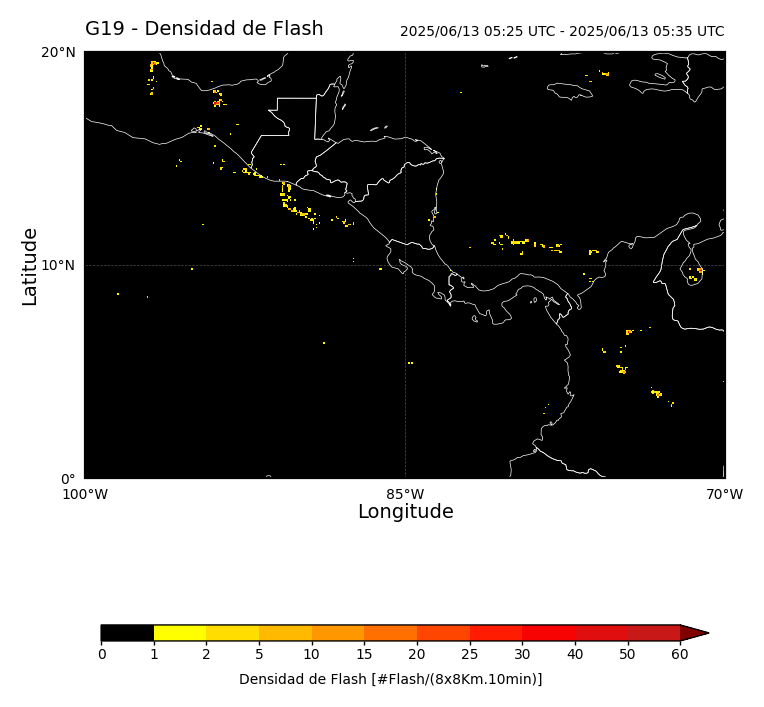

In [29]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

domain = [-100.0,-70.0,0.0,20.0]

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='white', linewidth=0.25) # Adicionamos los limites

#img = ax.pcolormesh(LonCor.data, LatCor.data, DC08C13, transform=proj_sat, cmap=cmap, norm=norm)
img = ax.pcolormesh(gridmap_LonCor.data, gridmap_LatCor.data, dens.data, cmap=cmap, norm=norm, transform=proj_sat)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='max', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - {}'.format(sat, title), fontsize=7, loc='left')
ax.set_title('{:%Y/%m/%d %H:%M UTC} - {:%Y/%m/%d %H:%M UTC}'.format(time_start, time_end),
             fontsize=5, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_FlashDens.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [30]:
del ds, flash_lon, flash_lat, gridmap_LonCor, gridmap_LatCor, dens, img, fig

### Grafiquemos el canal 13 y los flashes:

In [31]:
# Obteniendo el dato (imagen de satélite)

import GOES

ds = GOES.open_dataset(file_c13) # Leemos el archivo nc

# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
domain = [-100.0,-20.0,-60.0,20.0] # Definimos el dominio de longitud y latitud
CMI, LonCor, LatCor = ds.image('CMI', lonlat='corner', domain=domain)

# Atributos del dato (imagen de satélite)
sat = ds.attribute('platform_ID')
band_id = ds.variable('band_id').data[0]
wl = ds.variable('band_wavelength').data[0]

time = CMI.time_bounds.data[0]
long_name = CMI.long_name # Lo obtenemos de CMI
units = CMI.units # Lo obtenemos de CMI
long_name = 'Temperatura de brillo'
units = '°C'

In [32]:
# Creación de una paleta de colores personalizada
import custom_color_palette as ccp
import matplotlib.pyplot as plt

# Definimos los colores y el intervalo que ocupa en la paleta
paleta_1 = [['maroon','red','darkorange','#ffff00','forestgreen','cyan','royalblue',(148/255,0/255,211/255)], # sequencia de colores o paleta de matplotlib
            ccp.range(-90.0,-30.0,1.0) # intervalo que abarcan los colores
            ]

paleta_2 = [plt.cm.Greys, # sequencia de colores o paleta de matplotlib
            ccp.range(-30.0,60.0,1.0), # intervalo que abarcan los colores
            [ccp.range(-90.0,60.0,1.0),-30.0,60.0] # parametro opcional que estira y recorta la paleta de colores
            ]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([paleta_1,  paleta_2], extend='both')
cbticks = ccp.range(-90,60,15)

In [33]:
# Obteniendo el dato (de la descarga eléctrica)

ds_GLM = GOES.open_mfdataset(GLM_files)

# Extraemos las coordenadas de los flashes
flash_lon = ds_GLM.variable('flash_lon')
flash_lat = ds_GLM.variable('flash_lat')

# Extraemos el rango de tiempo que abarcan todos los archivos
time_bounds = ds_GLM.variable('product_time_bounds')
time_start = time_bounds.data[0,0]
time_end = time_bounds.data[-1,-1]

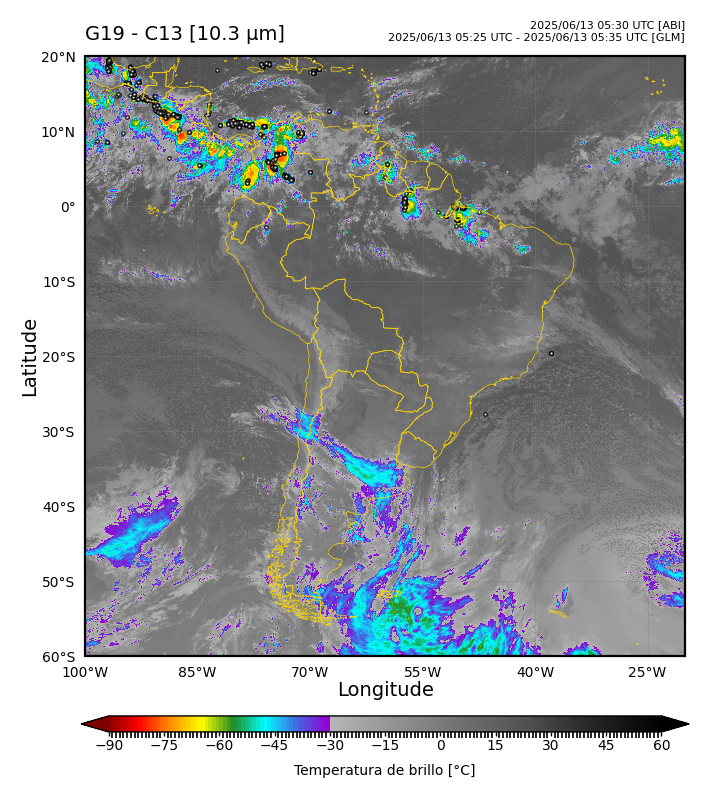

In [34]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, CMI.data-273.15, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='both', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Adiciona los Flashes
img2 = ax.scatter(flash_lon.data, flash_lat.data, s=1.5, c='white', marker='o', edgecolors='black', linewidths=0.5, alpha=0.8, transform=ccrs.PlateCarree())

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm]'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title('{:%Y/%m/%d %H:%M UTC [ABI]}\n{:%Y/%m/%d %H:%M UTC} - {:%Y/%m/%d %H:%M UTC} [GLM]'.format(time, time_start, time_end),
             fontsize=4, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_C13Flash.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [35]:
del ds, CMI, LonCor, LatCor, ds_GLM, flash_lon, flash_lat, img, fig